In [59]:
import os
import numpy as np
import matplotlib.pyplot as plt
from liblinear.liblinearutil import train, predict
from scipy.optimize import fmin_tnc
import scipy.optimize as opt
import cv2
import copy

In [60]:
def logsumexp(x: np.ndarray) -> float:
    """Compute log(sum(exp(x))) such that max(x) is used to avoid overflow"""
    M = np.max(x)
    return M + np.log(np.sum(np.exp(x - M)))

In [61]:
def letter_to_index(letter: str) -> int:
    """Convert a letter to an index (0 for 'a', 1 for 'b', ..., 25 for 'z')."""
    return ord(letter) - ord('a')

In [62]:
def flatten_true_labels(word_list):
    """Flatten all true labels from a list of (X, y) words into one 1D list."""
    labels = []
    for X, y in word_list:
        labels.extend(list(np.asarray(y).reshape(-1).astype(int)))
    return labels

In [63]:
def letter_accuracy(pred_labels, true_labels):
    # check whether pred values and true labels are the same and returns the mean
    pred_labels = np.asarray(pred_labels).reshape(-1)
    true_labels = np.asarray(true_labels).reshape(-1)
    return np.mean(pred_labels == true_labels)

In [64]:
def viterbi_decode_WTX(X, W, T):
    """
    Backward DP in log-space for CRF.
    Returns beta of shape (n, K).
    beta[s,i] = log sum of all suffix path scores from position s+1..n-1
                given y_s = i
    """

    n, d = X.shape
    K = W.shape[0]

    # Emission scores: A[s, j] = W[j] · X[s]
    A = X @ W.T  # (n, K)

    beta = np.zeros((n, K), dtype=np.float64)  # beta[n-1,:] = 0

    for s in range(n - 2, -1, -1):
        # for each current label i, sum over next label j
        # beta[s,i] = logsumexp_j( T[i,j] + A[s+1,j] + beta[s+1,j] )
        beta[s, :] = logsumexp(T + (A[s + 1, :] + beta[s + 1, :])[None, :], axis=1)
    
    delta = np.zeros((n, K), dtype=np.float64)
    DP = np.zeros((n, K), dtype=np.int32)

    delta[0, :] = A[0, :]
    for s in range(1, n):
        scores = delta[s - 1][:, None] + T  # (K, K): prev i -> curr j
        DP[s, :] = np.argmax(scores, axis=0)
        delta[s, :] = np.max(scores, axis=0) + A[s, :]

    y_pred = np.zeros(n, dtype=np.int32)
    y_pred[n - 1] = np.argmax(delta[n - 1, :])
    for s in range(n - 2, -1, -1):
        y_pred[s] = DP[s + 1, y_pred[s + 1]]

    return beta, y_pred

In [65]:
def score_function(X, y, W, T):
    """Compute the score of a sequence (X,y) given model parameters W and T"""
    score = 0.0
    n = X.shape[0]
    for s in range(n-1):
        score += W[y[s]].dot(X[s]) + T[y[s], y[s+1]]

    score += W[y[n-1]].dot(X[n-1])

    return score

In [66]:
def compute_Z_forward(X, W, T):
    """Compute the partition function Z(X) for a sequence X given model parameters W and T"""
    
    # Using dynamic progrmming to compute the partition function Z(X)
    n, d = X.shape
    K, dW = W.shape

    alpha = np.zeros((n, K), dtype = np.float64)

    # Pre-compute the A matrix which is the score of each letter at each position without transition scores
    A = X @ W.T
    alpha[0, :] = A[0, :]

    """Iterate through the sequence and compute the alpha values using the A matrix and transition scores T.
    This is the forward pass for computing the partition function Z(X)"""
    for s in range(1, n):
        for j in range(K):
            prev_terms = alpha[s-1, :] + T[:, j]
            alpha[s, j] = logsumexp(prev_terms) + A[s, j]
        
    logZ = logsumexp(alpha[n-1, :])
    
    return logZ, alpha

In [67]:
def compute_node_marginals(alpha, beta, logZ):
    """Compute the node marginals p(y_s | X) for each position s given alpha, beta, and logZ"""
    n, K = alpha.shape
    node_marginals = np.zeros((n, K), dtype=np.float64)

    # node_marginals measure the probability of each label at each position given the sequence X, and are computed using the alpha and beta values from the forward and backward passes, normalized by the partition function Z(X).
    for s in range(n):
        log_prob = alpha[s, :] + beta[s, :] - logZ
        
        """ probs are the unnormalized probabilities of each label at position s, computed by exponentiating the log probabilities. 
        To avoid numerical instability, we subtract the maximum log probability m from log_prob before exponentiating, 
        which ensures that we are working with smaller numbers and prevents overflow."""
        m = np.max(log_prob)
        probs = np.exp(log_prob - m)
        node_marginals[s, :] = probs / np.sum(probs)

    return node_marginals

In [68]:
def compute_edge_marginals(X, W, T, alpha, beta, logZ):
    """Compute the edge marginals p(y_s, y_{s+1} | X) for each position s given X, W, T, alpha, beta, and logZ"""
    n, d = X.shape
    K = W.shape[0]
    edge_marginals = np.zeros((n-1, K, K), dtype=np.float64)

    # edge_marginals measure the joint probability of pairs of labels at adjacent positions given the sequence X, and are computed using the alpha and beta values from the forward and backward passes, along with the model parameters W and T, normalized by the partition function Z(X).
    A = X @ W.T

    # log_probs are the unnormalized log probabilities of each pair of labels at positions s and s+1, computed using the alpha values at position s, the transition scores T, the A matrix for the scores of each label at each position, and the beta values at position s+1.
    for s in range(n-1):
        log_probs = (alpha[s][:, None]
                     + T
                     + A[s+1][None, :]
                     + beta[s+1][None, :]
                     - logZ)

        # To avoid numerical overflow, subtract the maximum log probability from each log probability before exponentiating
        m = np.max(log_probs)
        probs = np.exp(log_probs - m)
        edge_marginals[s] = probs / np.sum(probs)

    return edge_marginals

In [69]:
def gradient_loglikelihood(X, y, W, T):
    """Compute the gradient of the log likelihood with respect to W and T for a single sequence (X,y)"""
    n, d = X.shape
    K = W.shape[0]

    # Compute the node and edge marginals
    logZ, alpha = compute_Z_forward(X, W, T)
    beta, y_pred = viterbi_decode_WTX(X, W, T)
    node_marginals = compute_node_marginals(alpha, beta, logZ)
    edge_marginals = compute_edge_marginals(X, W, T, alpha, beta, logZ)

    # Initialize gradients
    grad_W = np.zeros_like(W)
    grad_T = np.zeros_like(T)

    # Compute the gradient with respect to W
    for s in range(n):
        grad_W[y[s]] += X[s]  
        grad_W -= node_marginals[s][:, None] * X[s]

    # Compute the gradient with respect to T
    for s in range(n-1):
        grad_T[y[s], y[s+1]] += 1
        grad_T -= edge_marginals[s]

    return grad_W, grad_T, y_pred

In [70]:
def get_crf_obj(word_list, W, T, c):
    """ Compute the negative log-likelihood of the CRF model with L2 regularization 
    given a list of sequences (word_list), model parameters W and T, and regularization strength c"""
    total_loglik = 0.0
    grad_W = np.zeros_like(W)
    grad_T = np.zeros_like(T)

    for X, y in word_list:
        score = score_function(X, y, W, T)
        logZ, _ = compute_Z_forward(X, W, T)
        dW, dT, _ = gradient_loglikelihood(X, y, W, T)  # gradient of (score - logZ)
        grad_W += dW
        grad_T += dT
        total_loglik += score - logZ

    # Negative log-likelihood + L2 regularization
    # -c * total_loglik + 0.5(||W||^2 + ||T||^2)
    obj = -c * total_loglik + 0.5 * (np.sum(W*W) + np.sum(T*T))

    return obj, grad_W, grad_T

In [71]:
def crf_obj(x, word_list, c):
    k, d = 26, 128
    x = np.asarray(x).ravel()
    W = x[:k*d].reshape(k, d)
    T = x[k*d:].reshape(k, k)
    
    # updates the value of grad_W and grad_T based on the current W and T, and computes the objective function value
    f, grad_W, grad_T = get_crf_obj(word_list, W, T, c)
    grad_W = -c * grad_W + W
    grad_T = -c * grad_T + T

    print("Optimal objective value:", f)

    g = np.concatenate([grad_W.reshape(-1), grad_T.reshape(-1)])
    return f, g

In [72]:
def crf_predict_all_letters(model, test_data):
    """
    model = flattened parameter vector [W, T]
    returns all predicted test letters as one flat list
    """
    x = np.asarray(model).ravel()
    W = x[:26 * 128].reshape(26, 128)
    T = x[26 * 128:].reshape(26, 26)

    preds = []
    for X, y in test_data:
        _, y_hat = viterbi_decode_WTX(X, W, T)
        preds.extend(list(np.asarray(y_hat).reshape(-1)))
    return np.array(preds)

In [73]:
def convert_words_to_letters(word_list):
    """
    For SVM-MC: convert OCR words into independent letter examples
    """
    X_all = []
    y_all = []

    for X, y in word_list:
        for i in range(X.shape[0]):
            X_all.append(X[i])
            y_all.append(int(y[i]))

    X_all = np.array(X_all, dtype=np.float64)
    y_all = np.array(y_all, dtype=int)
    return X_all, y_all

In [74]:
def ref_optimize(train_data, test_data, c):
    print('Training CRF ... c = {}\n'.format(c))

    # Initial value of the parameters W and T, stored in a vector
    x0 = np.zeros(128*26 + 26**2, dtype=np.float64)

    # Start the optimization
    result = opt.fmin_tnc(
        crf_obj,
        x0,
        args=[train_data, c],
        maxfun=100,
        ftol=1e-3,
        disp=5
    )

    model = result[0]

    return model

In [75]:
def run_crf(train_data, test_data, c):

    y_true = flatten_true_labels(test_data)

    result = ref_optimize(train_data, test_data, c)

    model = result

    y_pred = crf_predict_all_letters(model, test_data)

    acc = letter_accuracy(y_pred, y_true)

    return acc

In [76]:
def run_svm_mc(train_data, test_data, c):

    X_train, y_train = convert_words_to_letters(train_data)
    X_test, y_test = convert_words_to_letters(test_data)

    # LibLinear expects labels starting at 1
    if y_train.min() == 0:
        y_train_use = y_train + 1
        y_test_use = y_test + 1
        subtract_back = True
    else:
        y_train_use = y_train.copy()
        y_test_use = y_test.copy()
        subtract_back = False

    y_train_use = y_train_use.tolist()
    y_test_use = y_test_use.tolist()
    X_train_list = X_train.tolist()
    X_test_list = X_test.tolist()

    print(f"\n[SVM-MC] training with c = {c}")

    # -s 4 = Crammer-Singer multiclass SVM
    param = f"-s 4 -c {c} -q"
    model = train(y_train_use, X_train_list, param)

    p_label, p_acc, p_val = predict(y_test_use, X_test_list, model, "-q")
    y_pred = np.array(p_label, dtype=int)

    if subtract_back:
        y_pred = y_pred - 1
        y_true = y_test
    else:
        y_true = y_test_use

    acc = letter_accuracy(y_pred, y_true)

    return acc

In [77]:
def rotate_letter(x, angle):
    img = x.reshape(8,16)

    center = (8,4)
    M = cv2.getRotationMatrix2D(center, angle, 1)

    rotated = cv2.warpAffine(img, M, (16,8))

    return rotated.reshape(128)

In [78]:
def translate_letter(x, dx, dy):

    img = x.reshape(8, 16)

    # translation matrix
    M = np.float32([
        [1, 0, dx],
        [0, 1, dy]
    ])

    shifted = cv2.warpAffine(img, M, (16, 8))

    return shifted.reshape(128)

In [79]:
def distort_training_data(train_data, transforms, x):

    for i in range(x):

        t = transforms[i]

        if t[0] == "r":
            _, word_idx, angle = t

            word_idx -= 1  # convert to python index

            X, y = train_data[word_idx]

            for j in range(X.shape[0]):
                X[j] = rotate_letter(X[j], angle)

        elif t[0] == "t":
            _, word_idx, dx, dy = t

            word_idx -= 1

            X, y = train_data[word_idx]

            for j in range(X.shape[0]):
                X[j] = translate_letter(X[j], dx, dy)

    return train_data

In [80]:
def read_transformed_data(file_path):
    transforms = []

    with open(file_path, "r") as f:
        for line in f:
            parts = line.strip().split()

            if parts[0] == "r":
                # rotation
                transforms.append(("r", int(parts[1]), float(parts[2])))

            elif parts[0] == "t":
                # translation
                transforms.append(("t", int(parts[1]), int(parts[2]), int(parts[3])))

    return transforms

In [81]:
def translate_letter(x, dx, dy):
    # dx: horizontal shift (positive: right, negative: left)
    # dy: vertical shift (positive: down, negative: up)
    # The input x is a 128-dimensional vector representing an 8x16 image.
    # shift the image by dx pixels horizontally and dy pixels vertically, filling empty spaces with zeros.
    # M is the transformation matrix for translation, where the first row [1, 0, dx] indicates no change in x and a shift of dx, and the second row [0, 1, dy] indicates no change in y and a shift of dy.
    img = x.reshape(8,16)

    M = np.float32([[1,0,dx],
                    [0,1,dy]])
    
    # warpAffine applies the affine transformation defined by M to the image, resulting in a shifted image. The output size is specified as (16,8) to match the original dimensions of the image.
    shifted = cv2.warpAffine(img, M, (16,8))

    return shifted.reshape(128)

In [82]:
def load_data(path):
    sequences = []
    
    # Read the data file and parse each line
    with open(path, "r") as f:
        for raw in f:
            line = raw.strip()
            if not line:
                continue

            parts = line.split()
            label_char = parts[1]
            feats = [float(v) for v in parts[5:]]
            
            # X stores all values of the features, and y stores the label index
            """It skips first 4 values (word_id, label, word, word_length) and takes the rest as features"""
            X = np.array([feats], dtype=np.float64)         # (1, d)
            y = np.array([letter_to_index(label_char)], dtype=np.int64)  # (1,)
            sequences.append((X, y))

    return sequences

In [83]:
def plot_q5_results(x_values, crf_accs, svm_accs, title, ylabel):

    current_dir = os.getcwd()

    # project root (two levels up)
    project_root = os.path.dirname(os.path.dirname(current_dir))

    # result folder adjacent to code/
    results_dir = os.path.join(project_root, "result")

    plt.figure(figsize=(6,4))

    plt.plot(x_values, crf_accs, marker="o", label="CRF")
    plt.plot(x_values, svm_accs, marker="o", label="SVM-MC")

    plt.xlabel("Number of distortions applied")
    plt.ylabel(ylabel)
    plt.title(title)

    plt.grid(True)
    plt.legend()

    filename = title.replace(":", "").replace(" ", "_")
    save_path = os.path.join(results_dir, f"{filename}.png")

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print("Saved plot to:", save_path)

    plt.show()

In [86]:
def main():
    # Load the data
    current_dir = os.getcwd()

    # Go up two levels: Q4 -> code -> project root
    project_root = os.path.dirname(os.path.dirname(current_dir))

    data_path = os.path.join(project_root, "data", "train.txt")
    train_data = load_data(data_path)

    data_test_path = os.path.join(project_root, "data", "test.txt")
    test_data = load_data(data_test_path)

    data_transform_path = os.path.join(project_root, "data", "transform.txt")
    transforms = read_transformed_data(data_transform_path)

    x_values = [0, 500, 1000, 1500, 2000]

    crf_letter_acc = []
    svm_letter_acc = []

    best_crf_c = 100
    best_svm_c = 100

    for x in x_values:
        print(f"Running Q5 experiment with first {x} transformations")
        # start from clean training set every time
        distorted_train = copy.deepcopy(train_data)

        # apply first x transform instructions
        distored_train_data = distort_training_data(distorted_train, transforms, x)

        crf_acc = run_crf(distored_train_data, test_data, best_crf_c)
        crf_letter_acc.append(crf_acc)

        print(f"CRF letter accuracy: {crf_acc:.4f}")

        svm_acc =run_svm_mc(distored_train_data, test_data, best_svm_c)

        svm_letter_acc.append(svm_acc)

        print(f"SVM-MC letter accuracy: {svm_acc:.4f}")

    plot_q5_results(
        x_values,
        crf_letter_acc,
        svm_letter_acc,
        title="Q5a: Letter-wise Accuracy vs Number of Distortions",
        ylabel="Letter-wise Accuracy"
    )





Running Q5 experiment with first 0 transformations
Training CRF ... c = 100

Optimal objective value: 8455737.94512272
Optimal objective value: 8455737.92265352
Optimal objective value: 8455737.933844026
Optimal objective value: 8455737.943145422
Optimal objective value: 8455737.944716275
Optimal objective value: 4091341.091485916
Optimal objective value: 4933327.777630951
Optimal objective value: 4232231.242964711
Optimal objective value: 4109232.4278276954
Optimal objective value: 4089096.1114728022
Optimal objective value: 4089096.076923853
Optimal objective value: 4089096.0923863132
Optimal objective value: 4089096.0966443936
Optimal objective value: 4089096.0949444766
Optimal objective value: 4089096.100257595
Optimal objective value: 4089096.0996759725
Optimal objective value: 3143956.5936675477
Optimal objective value: 3225762.3507885695
Optimal objective value: 3081554.57191414
Optimal objective value: 3081554.544648302
Optimal objective value: 3081554.5667032255
Optimal object

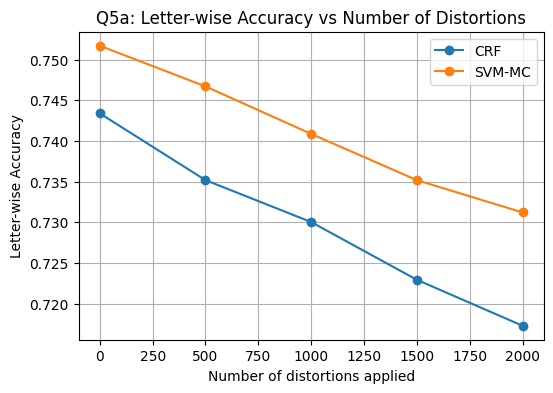

In [88]:
if __name__ == "__main__":
    main()